In [103]:
import pandas as pd
import matplotlib.pyplot as plt

In [104]:
df =pd.read_csv(r"C:\Users\sande\Downloads\archive (2)\Global_AI_Content_Impact_Dataset.csv")

In [105]:
df


,Country,Year,Industry,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Top AI Tools Used,Regulation Status,Consumer Trust in AI (%),Market Share of AI Companies (%)
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41
...,...,...,...,...,...,...,...,...,...,...,...,...
195,Germany,2021,Automotive,89.44,52.98,48.47,12.14,30.60,DALL-E,Lenient,77.21,44.35
196,Germany,2020,Media,70.11,28.26,27.62,57.86,58.71,DALL-E,Strict,78.74,31.73
197,France,2023,Marketing,65.77,49.83,39.94,79.44,43.73,Synthesia,Lenient,81.58,14.62
198,Australia,2023,Automotive,45.35,20.49,33.21,50.50,41.73,Claude,Strict,47.42,43.11


In [106]:
# View the first 5 rows
print(df.head())

       Country  Year    Industry  AI Adoption Rate (%)  \
0  South Korea  2022       Media                 44.29   
1        China  2025       Legal                 34.75   
2          USA  2022  Automotive                 81.06   
3       France  2021       Legal                 85.24   
4       France  2021      Gaming                 78.95   

   AI-Generated Content Volume (TBs per year)  Job Loss Due to AI (%)  \
0                                       33.09                   16.77   
1                                       66.74                   46.89   
2                                       96.13                   10.66   
3                                       93.76                   27.70   
4                                       45.62                   17.45   

   Revenue Increase Due to AI (%)  Human-AI Collaboration Rate (%)  \
0                           46.12                            74.79   
1                           52.46                            26.17   
2 

In [107]:
# Check data types and missing values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country                                     200 non-null    object 
 1   Year                                        200 non-null    int64  
 2   Industry                                    200 non-null    object 
 3   AI Adoption Rate (%)                        200 non-null    float64
 4   AI-Generated Content Volume (TBs per year)  200 non-null    float64
 5   Job Loss Due to AI (%)                      200 non-null    float64
 6   Revenue Increase Due to AI (%)              200 non-null    float64
 7   Human-AI Collaboration Rate (%)             200 non-null    float64
 8   Top AI Tools Used                           200 non-null    object 
 9   Regulation Status                           200 non-null    object 
 10  Consumer Trust

In [108]:
# Summary statistics
print(df.describe())

              Year  AI Adoption Rate (%)  \
count   200.000000            200.000000   
mean   2022.315000             54.265850   
std       1.825496             24.218067   
min    2020.000000             10.530000   
25%    2021.000000             33.222500   
50%    2022.000000             53.310000   
75%    2024.000000             76.220000   
max    2025.000000             94.760000   

       AI-Generated Content Volume (TBs per year)  Job Loss Due to AI (%)  \
count                                   200.00000              200.000000   
mean                                     46.07260               25.788250   
std                                      29.16122               13.901105   
min                                       1.04000                0.090000   
25%                                      20.32250               14.995000   
50%                                      44.32000               25.735000   
75%                                      71.62000               

#  Analyze Trends Over Years

In [109]:
# Group data by Year and calculate mean adoption rate
yearly_adoption = df.groupby('Year')['AI Adoption Rate (%)'].mean()

In [110]:
yearly_adoption

Year
2020    50.992766
2021    57.571875
2022    52.988065
2023    59.677241
2024    51.258696
2025    54.262895
Name: AI Adoption Rate (%), dtype: float64

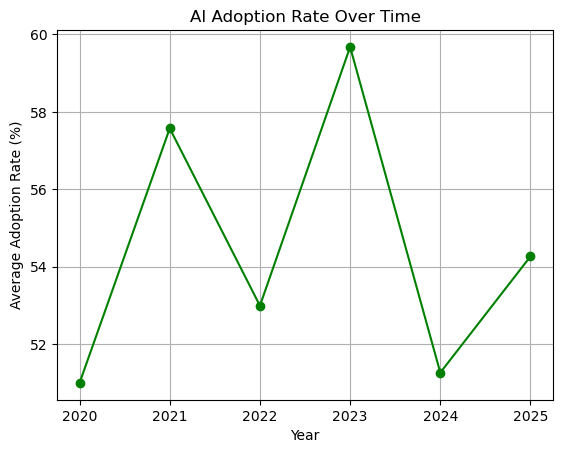

In [111]:
# Plot
yearly_adoption.plot(kind='line', marker='o', color='green')
plt.title("AI Adoption Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Average Adoption Rate (%)")
plt.grid(True)
plt.show()

# Compare Countries

In [112]:
# Top 5 countries by average AI adoption
country_adoption = df.groupby('Country')['AI Adoption Rate (%)'].mean().sort_values(ascending=False)
country_adoption

Country
UK             64.692000
France         56.518333
Australia      56.082000
Japan          54.209545
China          52.889048
Canada         52.190000
USA            52.080952
India          51.814583
Germany        51.460000
South Korea    50.563500
Name: AI Adoption Rate (%), dtype: float64

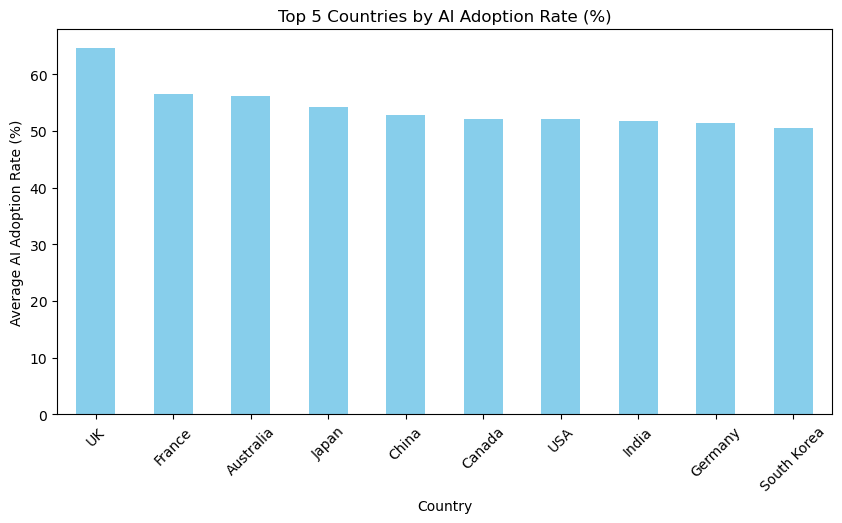

In [113]:
# Plot
plt.figure(figsize=(10, 5))
country_adoption.plot(kind='bar', color='skyblue')
plt.title('Top 5 Countries by AI Adoption Rate (%)')
plt.xlabel('Country')
plt.ylabel('Average AI Adoption Rate (%)')
plt.xticks(rotation=45)
plt.show()

# Industry-Specific Analysis

In [114]:
industry_tools = df.groupby('Industry')['Top AI Tools Used'].value_counts().unstack().fillna(0)

In [115]:
industry_tools

Top AI Tools Used,Bard,ChatGPT,Claude,DALL-E,Midjourney,Stable Diffusion,Synthesia
Industry,,,,,,,
Automotive,1.0,3.0,3.0,5.0,3.0,1.0,3.0
Education,2.0,4.0,3.0,1.0,1.0,4.0,2.0
Finance,2.0,1.0,3.0,0.0,4.0,2.0,2.0
Gaming,4.0,4.0,3.0,2.0,6.0,5.0,3.0
Healthcare,1.0,4.0,3.0,1.0,4.0,3.0,1.0
Legal,3.0,0.0,1.0,5.0,3.0,2.0,3.0
Manufacturing,2.0,4.0,3.0,1.0,4.0,2.0,2.0
Marketing,2.0,4.0,2.0,3.0,3.0,2.0,3.0
Media,4.0,4.0,6.0,5.0,5.0,3.0,4.0


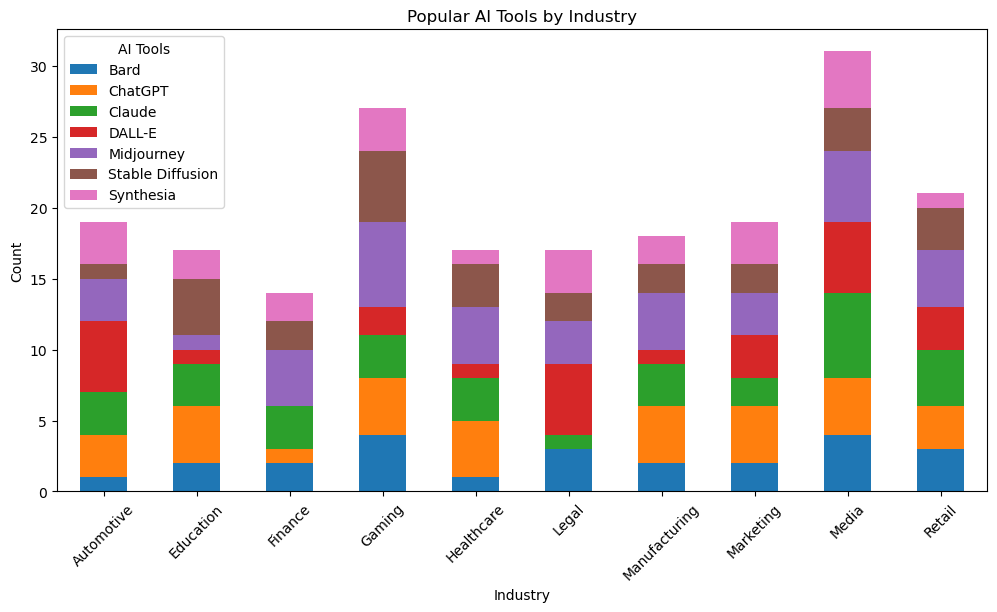

In [116]:
# Plot
industry_tools.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Popular AI Tools by Industry')
plt.xlabel('Industry')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='AI Tools')
plt.show()

# Relationship Between AI Adoption and Job Loss

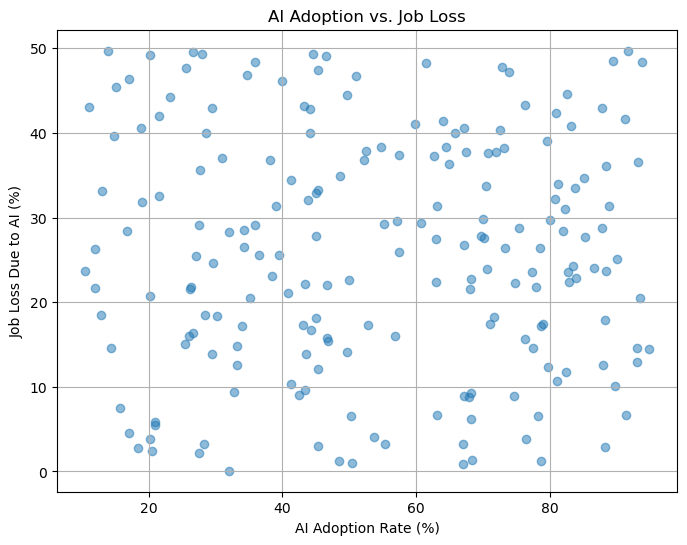

In [117]:
plt.figure(figsize=(8, 6))
plt.scatter(df['AI Adoption Rate (%)'], df['Job Loss Due to AI (%)'], alpha=0.5)
plt.title('AI Adoption vs. Job Loss')
plt.xlabel('AI Adoption Rate (%)')
plt.ylabel('Job Loss Due to AI (%)')
plt.grid(True)
plt.show()

# Regulation Status Distribution

In [118]:
regulation_counts = df['Regulation Status'].value_counts()

In [119]:
regulation_counts

Moderate    76
Lenient     63
Strict      61
Name: Regulation Status, dtype: int64

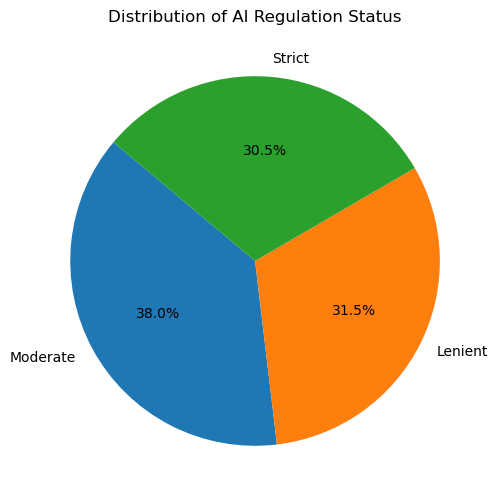

In [120]:
plt.figure(figsize=(8, 6))
regulation_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Distribution of AI Regulation Status')
plt.ylabel('')
plt.show()

# Temporal Trends: Industry-Specific AI Adoption

In [121]:
# Pivot table for heatmap
industry_year_adoption = df.pivot_table(
    index='Industry', 
    columns='Year', 
    values='AI Adoption Rate (%)', 
    aggfunc='mean'
)

In [122]:
industry_year_adoption

Year,2020,2021,2022,2023,2024,2025
Industry,,,,,,
Automotive,55.323333,67.940000,43.370000,45.350000,58.840000,92.960000
Education,63.845000,54.836667,43.850000,82.820000,NaN,43.573333
Finance,57.046000,14.760000,63.715000,64.653333,61.745000,35.830000
Gaming,50.970000,63.216667,75.508000,60.057500,49.880000,54.195000
Healthcare,33.263333,60.865000,54.066667,84.750000,51.410000,60.007500
Legal,51.570000,55.430000,42.440000,63.580000,62.545000,57.408000
Manufacturing,57.776667,49.685000,38.163333,78.570000,65.630000,78.270000
Marketing,48.743333,60.993333,73.890000,44.235000,58.486667,62.223333
Media,40.423333,60.416000,41.812000,60.118333,29.157500,56.435000


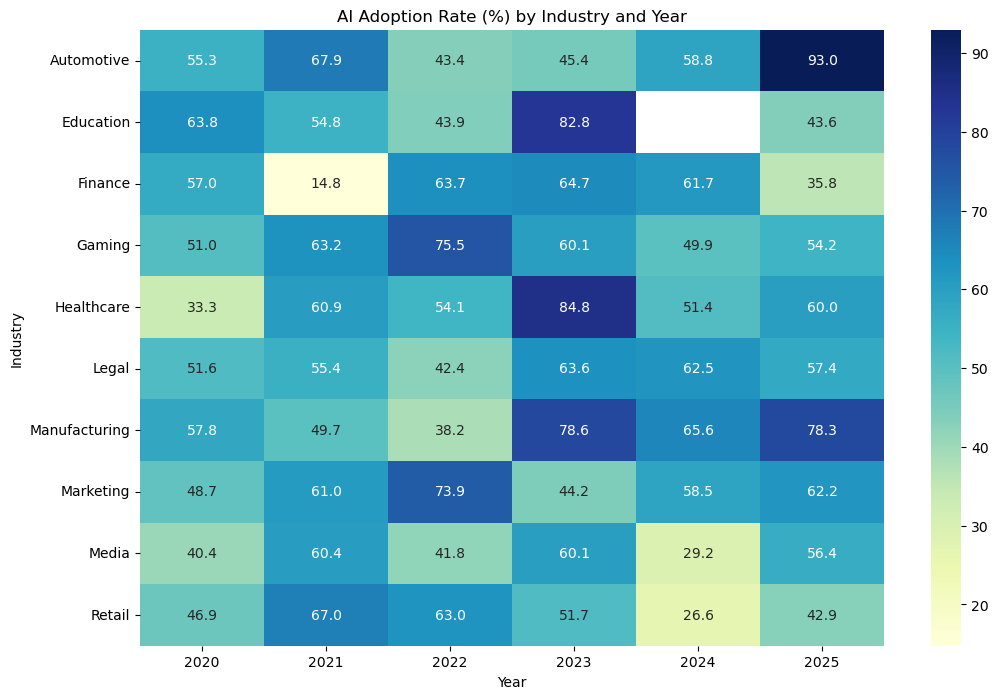

In [123]:
import seaborn as sns
# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(industry_year_adoption, annot=True, cmap='YlGnBu',fmt=".1f")
plt.title('AI Adoption Rate (%) by Industry and Year')
plt.xlabel('Year')
plt.ylabel('Industry')
plt.show()

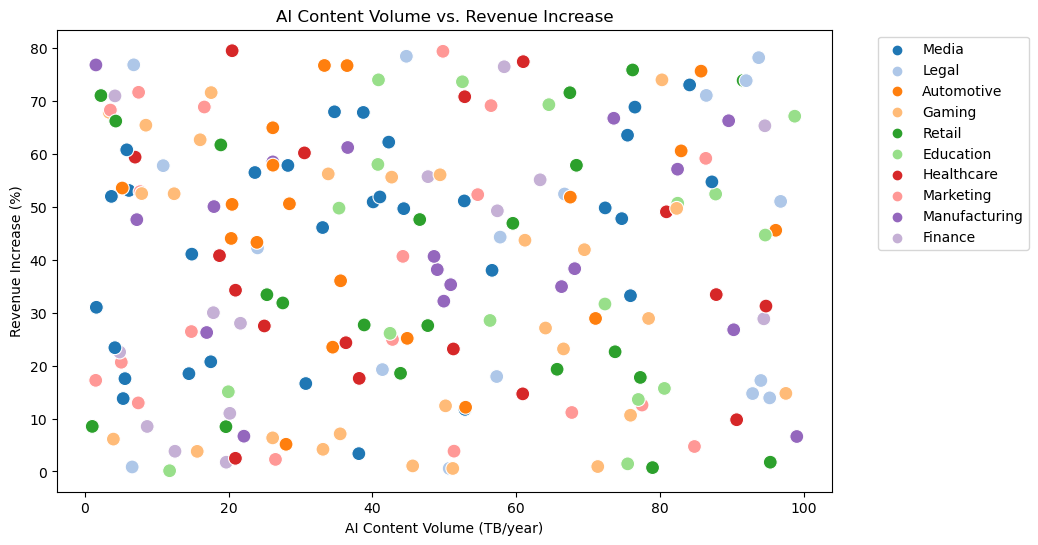

In [124]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='AI-Generated Content Volume (TBs per year)',
    y='Revenue Increase Due to AI (%)',
    hue='Industry',
    palette='tab20',
    s=100
)
plt.title('AI Content Volume vs. Revenue Increase')
plt.xlabel('AI Content Volume (TB/year)')
plt.ylabel('Revenue Increase (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

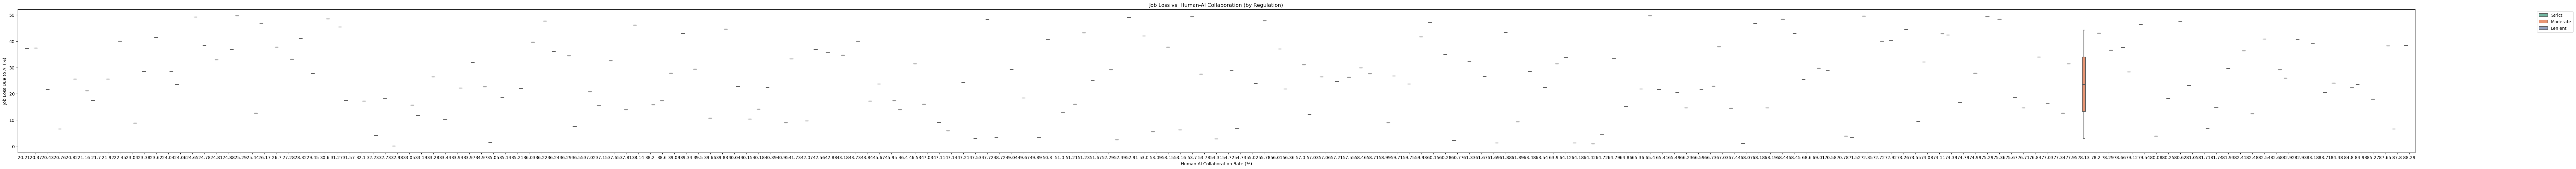

In [125]:
plt.figure(figsize=(100, 6))
sns.boxplot(
    data=df,
    x='Human-AI Collaboration Rate (%)',
    y='Job Loss Due to AI (%)',
    hue='Regulation Status',
    palette='Set2'
)
plt.title('Job Loss vs. Human-AI Collaboration (by Regulation)')
plt.xlabel('Human-AI Collaboration Rate (%)')
plt.ylabel('Job Loss Due to AI (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Tool Popularity by Industry

In [126]:
tool_industry = pd.crosstab(df['Industry'], df['Top AI Tools Used'])

In [127]:
tool_industry

Top AI Tools Used,Bard,ChatGPT,Claude,DALL-E,Midjourney,Stable Diffusion,Synthesia
Industry,,,,,,,
Automotive,1,3,3,5,3,1,3
Education,2,4,3,1,1,4,2
Finance,2,1,3,0,4,2,2
Gaming,4,4,3,2,6,5,3
Healthcare,1,4,3,1,4,3,1
Legal,3,0,1,5,3,2,3
Manufacturing,2,4,3,1,4,2,2
Marketing,2,4,2,3,3,2,3
Media,4,4,6,5,5,3,4


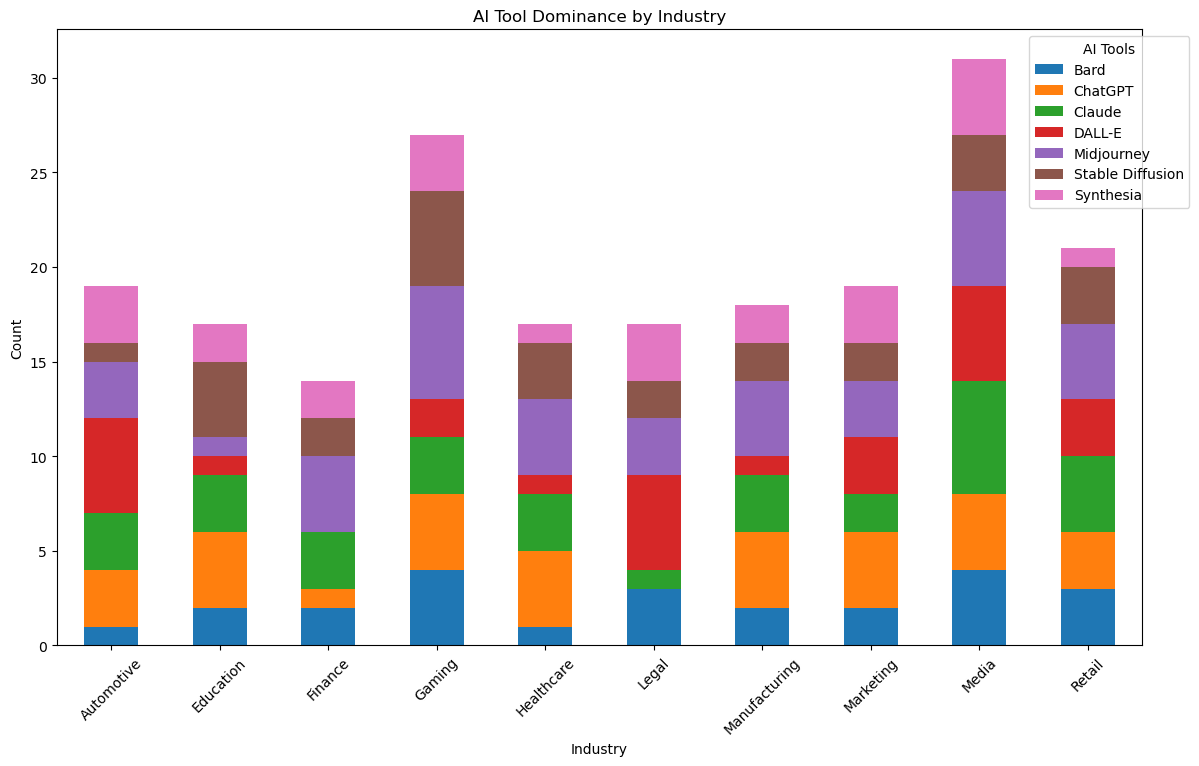

In [128]:
tool_industry.plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title('AI Tool Dominance by Industry')
plt.xlabel('Industry')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='AI Tools', bbox_to_anchor=(1.05, 1))
plt.show()

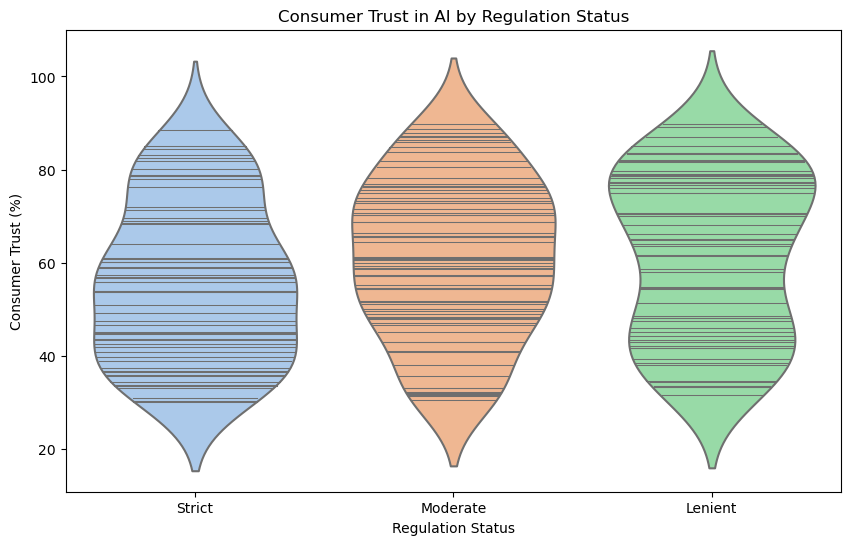

In [129]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x='Regulation Status',
    y='Consumer Trust in AI (%)',
    palette='pastel',
    inner='stick'
)
plt.title('Consumer Trust in AI by Regulation Status')
plt.xlabel('Regulation Status')
plt.ylabel('Consumer Trust (%)')
plt.show()

# Market Share of AI Companies by Country

In [130]:
top_countries = df.groupby('Country')['Market Share of AI Companies (%)'].mean().nlargest(5)

In [131]:
top_countries

Country
Germany        30.458235
India          28.335417
Canada         28.276875
South Korea    27.330500
France         27.189167
Name: Market Share of AI Companies (%), dtype: float64

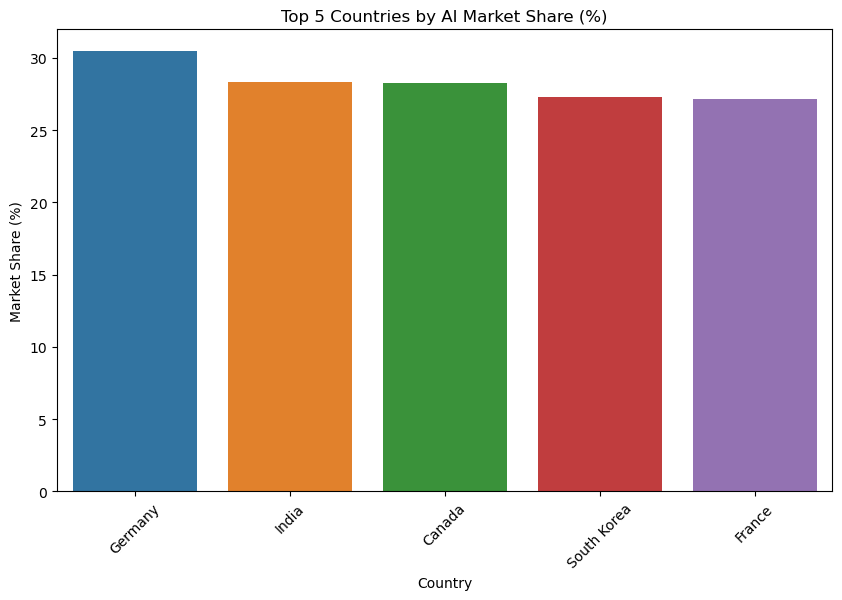

In [132]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)
plt.title('Top 5 Countries by AI Market Share (%)')
plt.xlabel('Country')
plt.ylabel('Market Share (%)')
plt.xticks(rotation=45)
plt.show()